<a href="https://colab.research.google.com/github/KateArch/TravelTide/blob/main/TravelTide_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
customers = pd.read_csv("/content/sample_data/customers.csv",index_col="user_id")
customers

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,home_city,home_airport,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
user_id,,,,,,,,,,,,,,,,
23557,82,8,76.625000,0.000000,66,F,True,False,usa,new york,LGA,2,0,3670.5,0.00,0.000000
94883,73,8,67.750000,0.500000,52,F,True,False,usa,kansas city,MCI,2,4,130.0,6.50,1451.335404
101486,131,8,122.250000,0.000000,52,F,True,True,usa,tacoma,TCM,2,2,2199.0,9.00,995.681600
101961,126,8,117.750000,0.400000,44,F,True,False,usa,boston,BOS,5,10,2429.0,5.60,1366.569097
106907,240,8,758.915066,5.000000,46,F,True,True,usa,miami,TNT,0,0,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,114,8,106.875000,0.500000,47,F,False,False,usa,kansas city,MCI,4,8,144.0,4.75,1459.165621
796032,148,8,545.319542,1.250000,52,F,True,False,canada,winnipeg,YAV,2,4,1261.0,7.00,1876.245079
801660,115,8,106.000000,0.333333,55,F,True,True,canada,toronto,YKZ,3,6,872.0,6.00,710.553530


In [ ]:
customers["gender"].value_counts()

,count
gender,
F,5292
M,695
O,11


In [ ]:
customers["home_country"].value_counts()

,count
home_country,
usa,4991
canada,1007


In [ ]:
customers["married"] = customers["married"].astype("int")
customers["has_children"] = customers["has_children"].astype("int")

customers["gender"] = (customers["gender"] == 'F').astype("int")
customers["home_country"] = (customers["home_country"] == 'canada').astype("int")
customers

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,home_city,home_airport,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
user_id,,,,,,,,,,,,,,,,
23557,82,8,76.625000,0.000000,66,1,1,0,0,new york,LGA,2,0,3670.5,0.00,0.000000
94883,73,8,67.750000,0.500000,52,1,1,0,0,kansas city,MCI,2,4,130.0,6.50,1451.335404
101486,131,8,122.250000,0.000000,52,1,1,1,0,tacoma,TCM,2,2,2199.0,9.00,995.681600
101961,126,8,117.750000,0.400000,44,1,1,0,0,boston,BOS,5,10,2429.0,5.60,1366.569097
106907,240,8,758.915066,5.000000,46,1,1,1,0,miami,TNT,0,0,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,114,8,106.875000,0.500000,47,1,0,0,0,kansas city,MCI,4,8,144.0,4.75,1459.165621
796032,148,8,545.319542,1.250000,52,1,1,0,1,winnipeg,YAV,2,4,1261.0,7.00,1876.245079
801660,115,8,106.000000,0.333333,55,1,1,1,1,toronto,YKZ,3,6,872.0,6.00,710.553530


In [ ]:
customers = customers.drop(["home_city","home_airport"],axis=1)
customers

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
user_id,,,,,,,,,,,,,,
23557,82,8,76.625000,0.000000,66,1,1,0,0,2,0,3670.5,0.00,0.000000
94883,73,8,67.750000,0.500000,52,1,1,0,0,2,4,130.0,6.50,1451.335404
101486,131,8,122.250000,0.000000,52,1,1,1,0,2,2,2199.0,9.00,995.681600
101961,126,8,117.750000,0.400000,44,1,1,0,0,5,10,2429.0,5.60,1366.569097
106907,240,8,758.915066,5.000000,46,1,1,1,0,0,0,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,114,8,106.875000,0.500000,47,1,0,0,0,4,8,144.0,4.75,1459.165621
796032,148,8,545.319542,1.250000,52,1,1,0,1,2,4,1261.0,7.00,1876.245079
801660,115,8,106.000000,0.333333,55,1,1,1,1,3,6,872.0,6.00,710.553530


In [ ]:
customers.describe(include = "all")

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
count,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000
mean,144.308436,8.204568,187.060316,0.518031,42.473825,0.882294,0.440480,0.326442,0.167889,2.582361,4.291097,1757.946315,10.461487,1874.112150
std,72.330165,0.460911,241.058619,0.516093,12.046872,0.322286,0.496486,0.468950,0.373799,1.533290,2.986260,2070.992742,28.836139,1598.239400
min,33.000000,8.000000,31.500000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,102.000000,8.000000,93.000000,0.000000,35.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,411.000000,5.000000,1006.493564
50%,127.000000,8.000000,116.375000,0.500000,43.000000,1.000000,0.000000,0.000000,0.000000,3.000000,4.000000,1146.100000,6.600000,1824.037125
75%,161.000000,8.000000,147.375000,1.000000,50.000000,1.000000,1.000000,1.000000,0.000000,4.000000,6.000000,2373.500000,8.000000,2512.142021
max,873.000000,12.000000,2137.625000,5.666667,89.000000,1.000000,1.000000,1.000000,1.000000,8.000000,16.000000,28114.000000,365.000000,22272.194376


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
customers_scaled = scaler.fit_transform(customers)

In [ ]:
customers_scaled

array([[-0.86151651, -0.44387174, -0.45816459, ...,  0.92357308,
        -0.36282108, -1.17270817],
       [-0.9859563 , -0.44387174, -0.49498443, ..., -0.78613604,
        -0.13739069, -0.2645486 ],
       [-0.184011  , -0.44387174, -0.26887949, ...,  0.21298503,
        -0.0506867 , -0.54966971],
       ...,
       [-0.40523729, -0.44387174, -0.3362961 , ..., -0.42782389,
        -0.15473149, -0.72808593],
       [-0.54350372, -0.44387174, -0.36481852, ..., -0.4374819 ,
        -0.0160051 ,  0.84415511],
       [-0.62646358, -0.44387174, -0.3897108 , ..., -0.8489131 ,
        -0.36282108, -1.17270817]])

In [ ]:
customers_scaled = pd.DataFrame(customers_scaled)
customers_scaled.index = customers.index
customers_scaled.columns = customers.columns
customers_scaled

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
user_id,,,,,,,,,,,,,,
23557,-0.861517,-0.443872,-0.458165,-1.003839,1.953049,0.365252,1.127054,-0.696171,-0.449181,-0.379843,-1.437067,0.923573,-0.362821,-1.172708
94883,-0.985956,-0.443872,-0.494984,-0.034941,0.790825,0.365252,1.127054,-0.696171,-0.449181,-0.379843,-0.097487,-0.786136,-0.137391,-0.264549
101486,-0.184011,-0.443872,-0.268879,-1.003839,0.790825,0.365252,1.127054,1.436430,-0.449181,-0.379843,-0.767277,0.212985,-0.050687,-0.549670
101961,-0.253144,-0.443872,-0.287549,-0.228720,0.126697,0.365252,1.127054,-0.696171,-0.449181,1.576897,1.911883,0.324052,-0.168604,-0.317590
106907,1.323093,-0.443872,2.372462,8.685138,0.292729,0.365252,1.127054,1.436430,-0.449181,-1.684337,-1.437067,-0.848913,-0.362821,-1.172708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,-0.419064,-0.443872,-0.332666,-0.034941,0.375745,0.365252,-0.887269,-0.696171,-0.449181,0.924651,1.242093,-0.779375,-0.198083,-0.259649
796032,0.051042,-0.443872,1.486315,1.418406,0.790825,0.365252,1.127054,-0.696171,2.226276,-0.379843,-0.097487,-0.239976,-0.120050,0.001335
801660,-0.405237,-0.443872,-0.336296,-0.357907,1.039873,0.365252,1.127054,1.436430,2.226276,0.272404,0.572303,-0.427824,-0.154731,-0.728086


In [ ]:
customers_scaled.describe()

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown
count,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03,5.998000e+03
mean,4.501605e-17,1.421559e-15,-2.191571e-17,-1.421559e-16,9.358599e-17,7.107797e-18,2.369266e-18,-1.006938e-17,4.501605e-17,6.633944e-17,9.477062e-18,-3.790825e-17,3.731593e-17,-3.316972e-17
std,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00,1.000083e+00
min,-1.539022e+00,-4.438717e-01,-6.453753e-01,-1.003839e+00,-2.031719e+00,-2.737837e+00,-8.872693e-01,-6.961706e-01,-4.491806e-01,-1.684337e+00,-1.437067e+00,-8.489131e-01,-3.628211e-01,-1.172708e+00
25%,-5.849836e-01,-4.438717e-01,-3.902294e-01,-1.003839e+00,-6.204472e-01,3.652519e-01,-8.872693e-01,-6.961706e-01,-4.491806e-01,-1.032090e+00,-7.672768e-01,-6.504410e-01,-1.894131e-01,-5.429042e-01
50%,-2.393176e-01,-4.438717e-01,-2.932532e-01,-3.494092e-02,4.368099e-02,3.652519e-01,-8.872693e-01,-6.961706e-01,-4.491806e-01,2.724038e-01,-9.748692e-02,-2.954609e-01,-1.339225e-01,-3.133398e-02
75%,2.307883e-01,-4.438717e-01,-1.646430e-01,9.339567e-01,6.247931e-01,3.652519e-01,1.127054e+00,1.436430e+00,-4.491806e-01,9.246506e-01,5.723029e-01,2.972512e-01,-8.536829e-02,3.992412e-01
max,1.007536e+01,8.235322e+00,8.092336e+00,9.977001e+00,3.862418e+00,3.652519e-01,1.127054e+00,1.436430e+00,2.226276e+00,3.533638e+00,3.921252e+00,1.272735e+01,1.229596e+01,1.276391e+01


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components = 0.9)
pca.fit(customers_scaled)

PCA(n_components=0.9)

In [ ]:
component_matrix = pd.DataFrame(pca.components_).T
component_matrix.columns = [f"pca_{i}"for i in range(component_matrix.shape[1])]
component_matrix.index = customers_scaled.columns
component_matrix

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
num_clicks,0.272042,0.634060,0.013508,-0.018664,0.041878,0.005930,-0.009745,0.009671,0.110533,-0.092774
num_sessions,0.069506,0.060336,0.136802,-0.046552,0.647330,-0.159400,0.153887,0.647035,-0.145127,0.239057
avg_session_duration,0.132308,0.686638,0.050648,0.043237,-0.021592,0.023814,-0.020971,-0.088591,0.136175,-0.035824
avg_bags,0.235582,0.075670,0.180360,0.265485,-0.202424,-0.063497,0.208652,-0.254632,-0.587737,0.574317
age,0.163127,-0.076710,0.562431,-0.249055,0.005336,0.138066,-0.339928,-0.019729,0.032885,-0.042138
gender,0.005489,-0.064422,0.049285,-0.041930,0.648821,0.157957,0.333834,-0.644809,0.031948,-0.123225
married,0.063388,-0.090836,0.672358,-0.138421,-0.056713,0.098739,-0.060604,-0.038787,0.111445,0.040305
has_children,-0.051908,-0.015701,0.307233,0.101292,-0.283293,-0.198405,0.755777,0.159603,0.115007,-0.353835
home_country,0.016419,0.012602,-0.080530,0.039143,-0.080051,0.932739,0.221410,0.243136,-0.047158,0.051895
num_trips,0.559790,-0.162000,-0.163893,-0.207790,-0.033373,-0.025231,0.062582,0.025648,-0.066946,-0.150279


<Axes: >

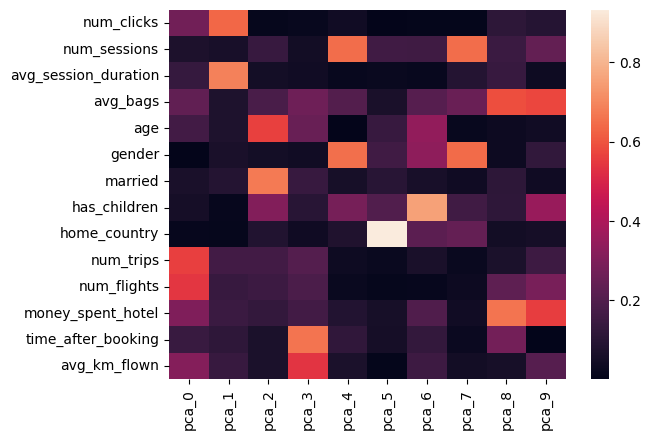

In [ ]:
sns.heatmap(np.abs(component_matrix))

In [ ]:
customers_pca = pca.fit_transform(customers_scaled)
customers_pca

array([[-1.26924723, -0.90556625,  1.47306284, ..., -0.69571827,
         1.43787714,  0.78058141],
       [-0.74570312, -0.93481168,  1.0862871 , ..., -0.75548686,
        -0.51241761, -0.12369035],
       [-0.97468401, -0.40132886,  1.54811212, ..., -0.25423672,
         1.24329204, -0.71098906],
       ...,
       [ 0.02150991, -0.68527901,  1.3391232 , ...,  0.30659322,
        -0.09887528, -0.98904108],
       [-1.29060676, -0.6518856 ,  1.54548887, ..., -0.16522923,
         0.87463368, -1.20679204],
       [-3.28597398,  0.37522184, -0.89489053, ...,  1.82849729,
         0.19391939, -0.33918453]])

In [ ]:
customers_pca = pd.DataFrame(customers_pca)
customers_pca.index = customers.index
customers_pca.columns = [f"pca_{i}"for i in range(customers_pca.shape[1])]
customers_pca

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
user_id,,,,,,,,,,
23557,-1.269247,-0.905566,1.473063,-1.672125,0.154529,0.245905,-1.137669,-0.695718,1.437877,0.780581
94883,-0.745703,-0.934812,1.086287,-0.457635,0.147232,0.102647,-1.019407,-0.755487,-0.512418,-0.123690
101486,-0.974684,-0.401329,1.548112,-0.637913,-0.309421,-0.288063,0.595990,-0.254237,1.243292,-0.710989
101961,1.827152,-1.034987,-0.067035,-1.351087,-0.004430,-0.107465,-0.462235,-0.637749,-0.175271,-0.523401
106907,0.335033,3.718160,3.553328,2.167956,-2.196309,-0.809532,2.548858,-2.979532,-4.525340,4.567391
...,...,...,...,...,...,...,...,...,...,...
792549,0.686769,-0.639507,-0.902803,-0.634124,0.197014,-0.201255,-0.654981,-0.602688,-1.069467,-0.822394
796032,0.434724,1.109376,1.197485,0.165461,-0.386844,2.527146,-0.109959,-0.650615,-0.727093,0.930841
801660,0.021510,-0.685279,1.339123,-0.864917,-0.684170,2.194975,1.216874,0.306593,-0.098875,-0.989041


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
scores = []
for n_clusters in range(2,20):
  kmeans = KMeans(n_clusters=n_clusters)
  groups = kmeans.fit_predict(customers_pca)
  scores.append(silhouette_score(customers_pca,groups))

[np.float64(0.13146117109421973),
 np.float64(0.1566298189140236),
 np.float64(0.14810514326406113),
 np.float64(0.15508859531144376),
 np.float64(0.16746147084922905),
 np.float64(0.17189894368925238),
 np.float64(0.18573681099509573),
 np.float64(0.18580731252427124),
 np.float64(0.15246937877480976),
 np.float64(0.17957862712692693),
 np.float64(0.19230491292195337),
 np.float64(0.16087951560420272),
 np.float64(0.1674834535414642),
 np.float64(0.16488383686534178),
 np.float64(0.16987650016890632),
 np.float64(0.1680899083803875),
 np.float64(0.16638153803965428),
 np.float64(0.17599607789125568)]

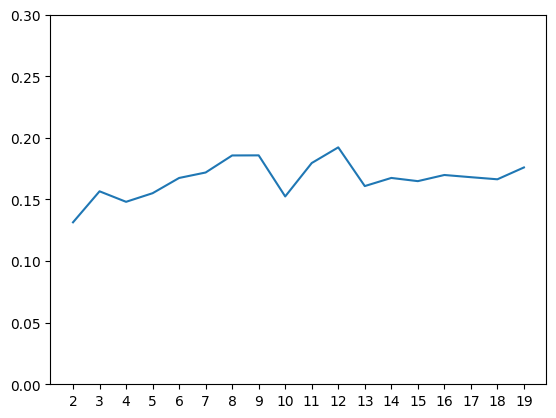

In [ ]:
ax = sns.lineplot(x=range(2,20),y=scores)
ax.set_xticks(range(2,20))
ax.set_ylim(0,0.3)
scores

In [ ]:
kmeans = KMeans(n_clusters=8)
groups = kmeans.fit_predict(customers_pca)

In [ ]:
groups

array([3, 3, 6, ..., 1, 7, 7], dtype=int32)

In [ ]:
groups = pd.Series(groups)
groups.index = customers.index
groups.name = "group"
groups

,group
user_id,
23557,3
94883,3
101486,6
101961,5
106907,2
...,...
792549,5
796032,1
801660,1


In [ ]:
pd.crosstab(groups,"count")

col_0,count
group,
0,895
1,757
2,442
3,844
4,102
5,1497
6,934
7,527


In [ ]:
customers_viz = pd.concat([customers_pca,groups],axis=1)
customers_viz

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,group
user_id,,,,,,,,,,,
23557,-1.269247,-0.905566,1.473063,-1.672125,0.154529,0.245905,-1.137669,-0.695718,1.437877,0.780581,3
94883,-0.745703,-0.934812,1.086287,-0.457635,0.147232,0.102647,-1.019407,-0.755487,-0.512418,-0.123690,3
101486,-0.974684,-0.401329,1.548112,-0.637913,-0.309421,-0.288063,0.595990,-0.254237,1.243292,-0.710989,6
101961,1.827152,-1.034987,-0.067035,-1.351087,-0.004430,-0.107465,-0.462235,-0.637749,-0.175271,-0.523401,5
106907,0.335033,3.718160,3.553328,2.167956,-2.196309,-0.809532,2.548858,-2.979532,-4.525340,4.567391,2
...,...,...,...,...,...,...,...,...,...,...,...
792549,0.686769,-0.639507,-0.902803,-0.634124,0.197014,-0.201255,-0.654981,-0.602688,-1.069467,-0.822394,5
796032,0.434724,1.109376,1.197485,0.165461,-0.386844,2.527146,-0.109959,-0.650615,-0.727093,0.930841,1
801660,0.021510,-0.685279,1.339123,-0.864917,-0.684170,2.194975,1.216874,0.306593,-0.098875,-0.989041,1


<Axes: xlabel='pca_0', ylabel='pca_1'>

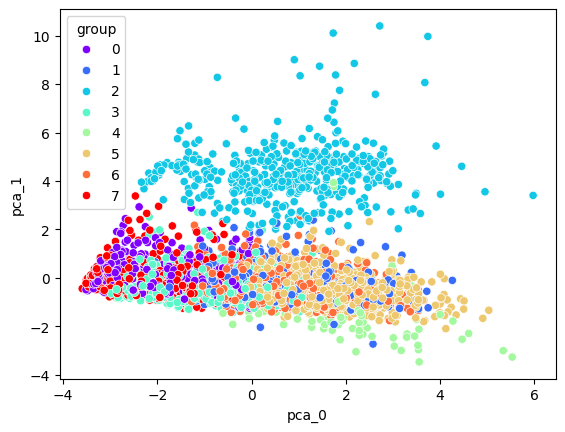

In [ ]:
sns.scatterplot(data=customers_viz,x="pca_0",y="pca_1",hue="group",palette="rainbow",legend='full')

In [ ]:
customers["group"] = groups
customers

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown,group
user_id,,,,,,,,,,,,,,,
23557,82,8,76.625000,0.000000,66,1,1,0,0,2,0,3670.5,0.00,0.000000,3
94883,73,8,67.750000,0.500000,52,1,1,0,0,2,4,130.0,6.50,1451.335404,3
101486,131,8,122.250000,0.000000,52,1,1,1,0,2,2,2199.0,9.00,995.681600,6
101961,126,8,117.750000,0.400000,44,1,1,0,0,5,10,2429.0,5.60,1366.569097,5
106907,240,8,758.915066,5.000000,46,1,1,1,0,0,0,0.0,0.00,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,114,8,106.875000,0.500000,47,1,0,0,0,4,8,144.0,4.75,1459.165621,5
796032,148,8,545.319542,1.250000,52,1,1,0,1,2,4,1261.0,7.00,1876.245079,1
801660,115,8,106.000000,0.333333,55,1,1,1,1,3,6,872.0,6.00,710.553530,1


In [ ]:
customers.loc[customers["num_trips"]==0,"group"].value_counts()

,count
group,
0,199
7,151
3,141
2,62
6,3


In [ ]:
pd.crosstab(customers["group"],customers["gender"])

gender,0,1
group,,
0,102,793
1,82,675
2,72,370
3,66,778
4,9,93
5,189,1308
6,97,837
7,89,438


In [ ]:
pd.crosstab(customers["group"],[customers["gender"],customers["has_children"]])

gender          0         1     
has_children    0   1     0    1
group                           
0             102   0   793    0
1              49  33   472  203
2              50  22   250  120
3              65   1   737   41
4               5   4    58   35
5             186   3  1269   39
6               0  97     3  834
7               1  88     0  438

In [ ]:
pd.crosstab(customers["group"],[customers["gender"],customers["has_children"],customers["home_country"]])

gender          0                 1               
has_children    0       1         0         1     
home_country    0   1   0   1     0    1    0    1
group                                             
0              91  11   0   0   736   57    0    0
1               0  49   0  33     0  472    0  203
2              39  11  19   3   213   37   98   22
3              64   1   1   0   703   34   38    3
4               4   1   4   0    40   18   28    7
5             186   0   3   0  1268    1   39    0
6               0   0  97   0     3    0  834    0
7               1   0  82   6     0    0  400   38

In [ ]:
customers.loc[customers["group"]==2,:].describe()

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown,group
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.0
mean,345.210407,8.264706,988.759022,0.745912,42.228507,0.837104,0.402715,0.321267,0.165158,2.006787,3.346154,1304.371833,5.930047,1708.139004,2.0
std,83.401923,0.559457,202.294226,0.765146,12.397235,0.369689,0.491000,0.467492,0.371744,1.313612,2.562612,1552.926800,6.685367,1313.464622,0.0
min,173.000000,8.000000,302.300000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
25%,288.250000,8.000000,919.845727,0.270833,34.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,258.500000,4.125000,578.667000,2.0
50%,330.000000,8.000000,999.625000,0.666667,43.000000,1.000000,0.000000,0.000000,0.000000,2.000000,4.000000,884.500000,6.291667,1762.677914,2.0
75%,396.000000,8.000000,1068.750000,1.000000,49.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,1732.750000,8.000000,2518.958939,2.0
max,873.000000,11.000000,2137.625000,5.666667,81.000000,1.000000,1.000000,1.000000,1.000000,7.000000,14.000000,10686.000000,106.333333,8809.999266,2.0


In [ ]:
customers

,num_clicks,num_sessions,avg_session_duration,avg_bags,age,gender,married,has_children,home_country,num_trips,num_flights,money_spent_hotel,time_after_booking,avg_km_flown,group
user_id,,,,,,,,,,,,,,,
23557,82,8,76.625000,0.000000,66,1,1,0,0,2,0,3670.5,0.00,0.000000,3
94883,73,8,67.750000,0.500000,52,1,1,0,0,2,4,130.0,6.50,1451.335404,3
101486,131,8,122.250000,0.000000,52,1,1,1,0,2,2,2199.0,9.00,995.681600,6
101961,126,8,117.750000,0.400000,44,1,1,0,0,5,10,2429.0,5.60,1366.569097,5
106907,240,8,758.915066,5.000000,46,1,1,1,0,0,0,0.0,0.00,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,114,8,106.875000,0.500000,47,1,0,0,0,4,8,144.0,4.75,1459.165621,5
796032,148,8,545.319542,1.250000,52,1,1,0,1,2,4,1261.0,7.00,1876.245079,1
801660,115,8,106.000000,0.333333,55,1,1,1,1,3,6,872.0,6.00,710.553530,1


KeyboardInterrupt: 

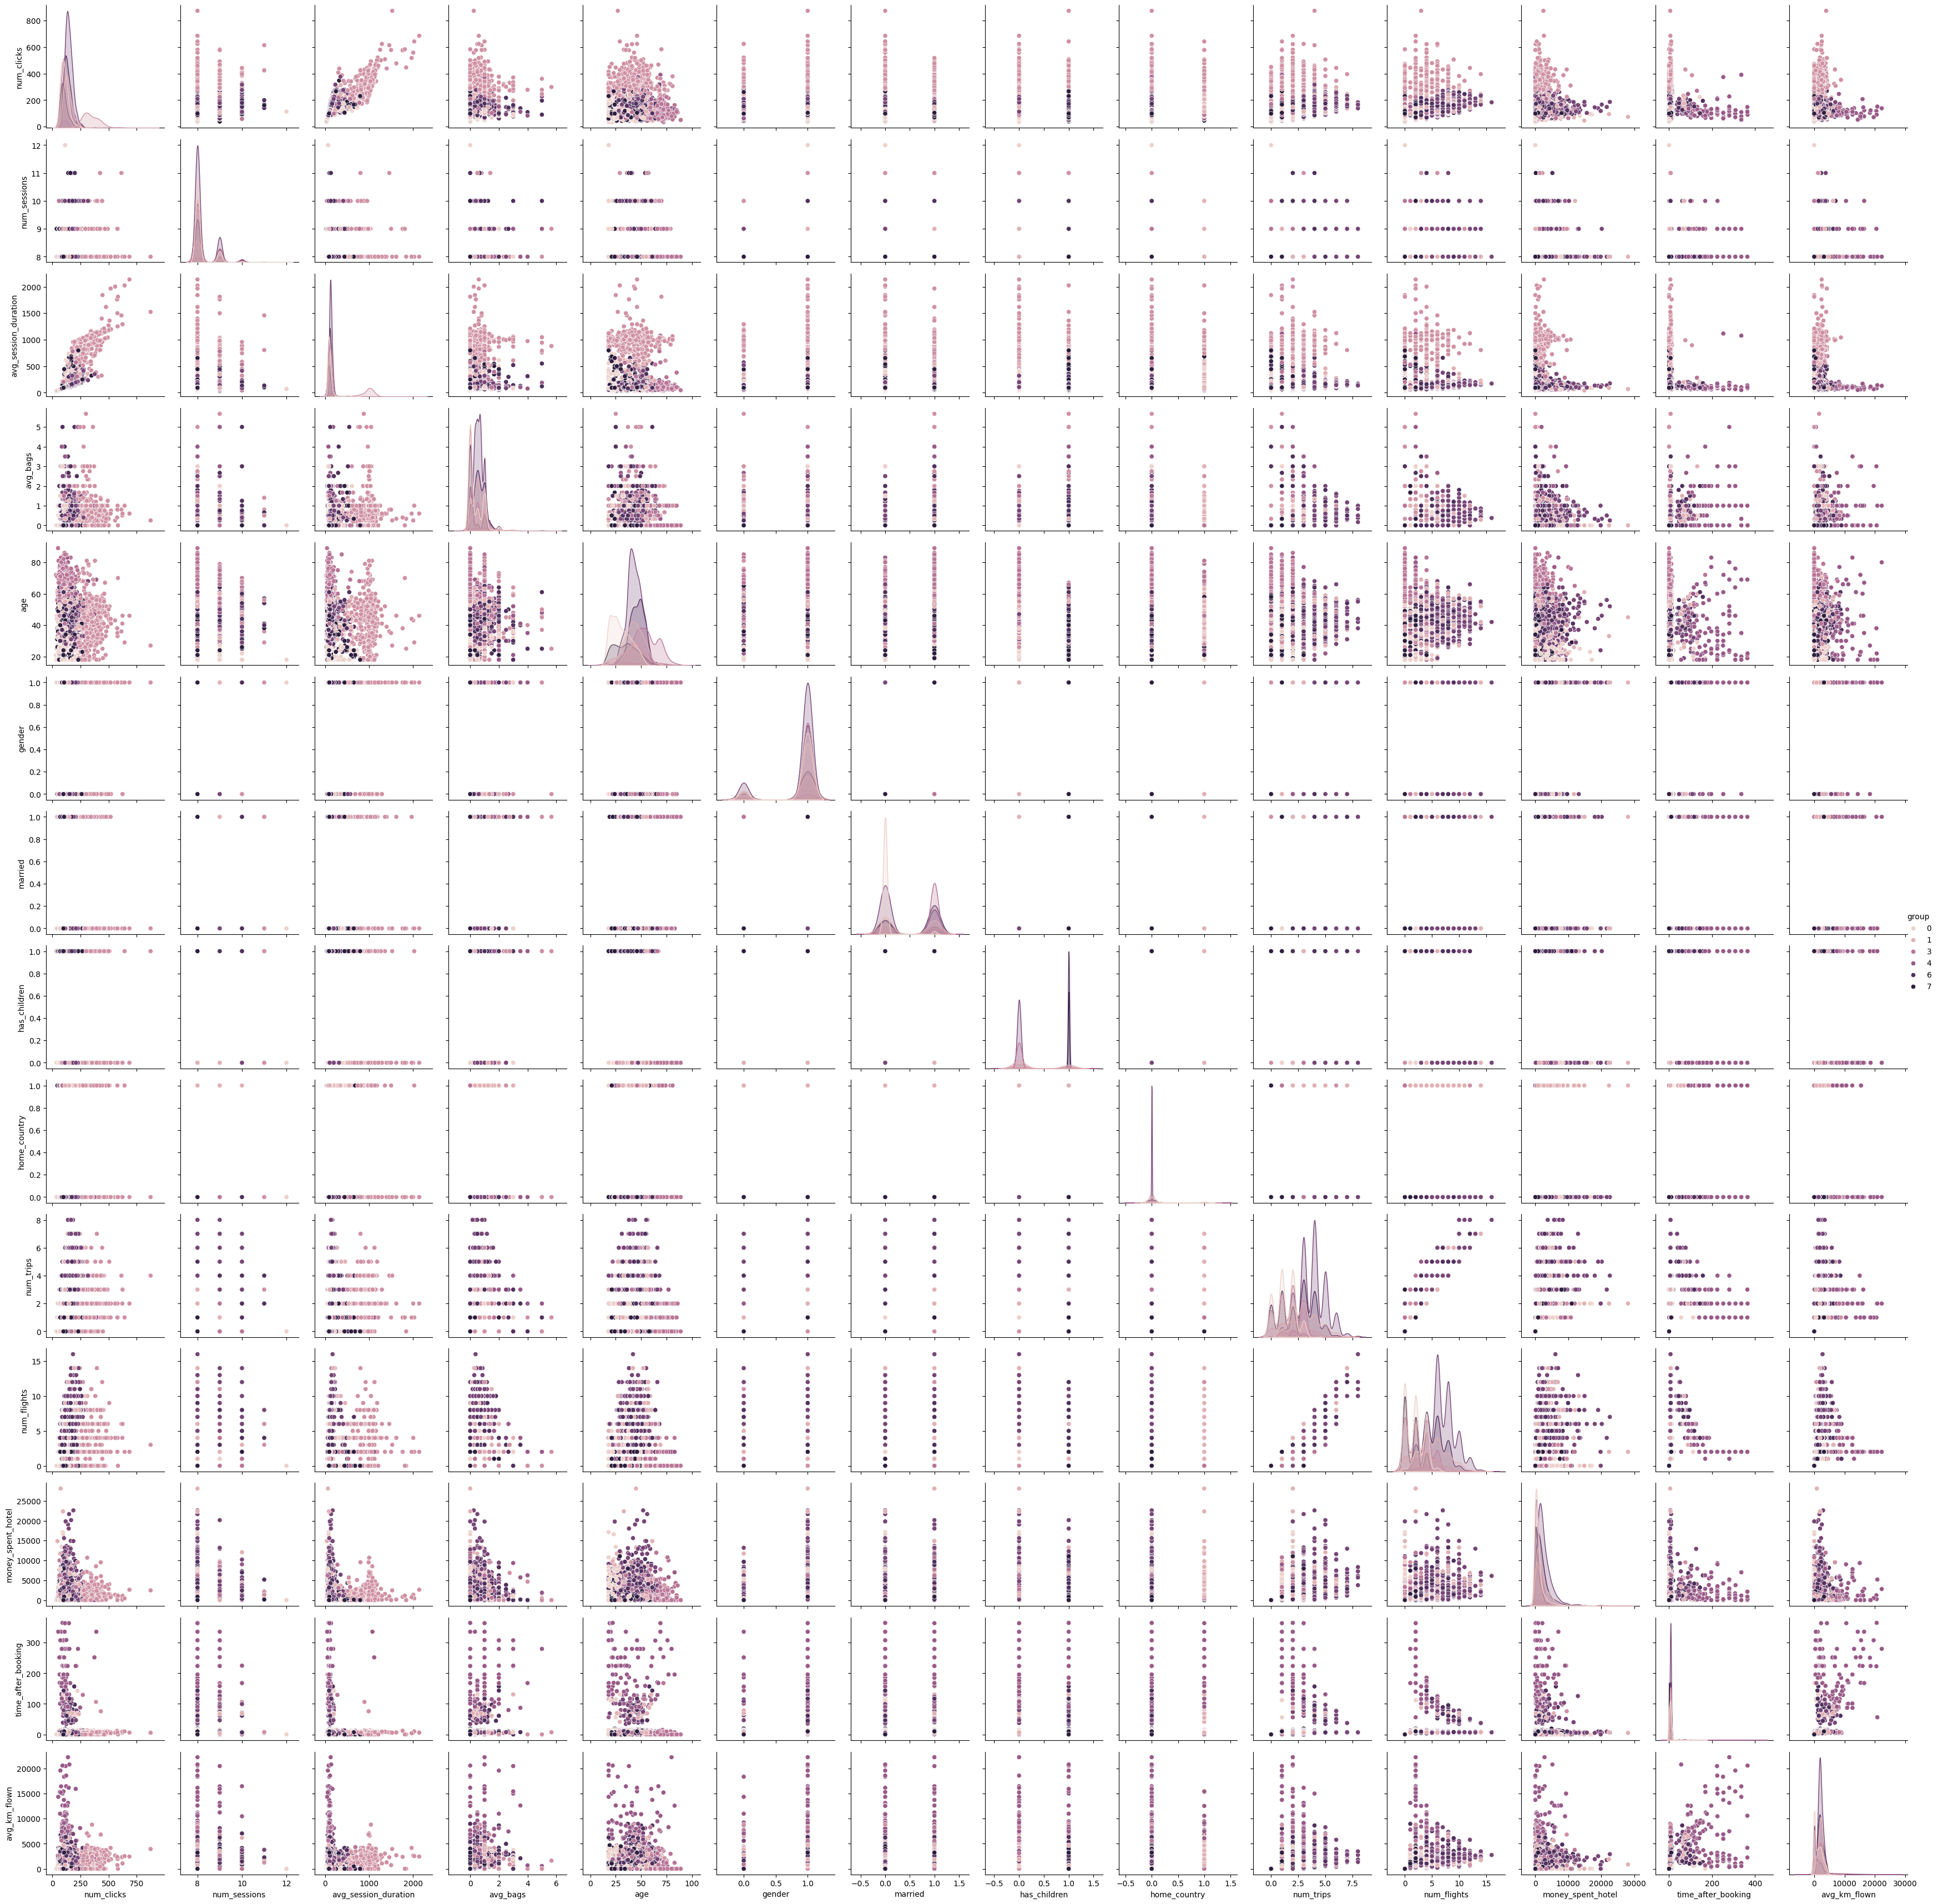

In [ ]:
sns.pairplot(customers,hue="group")